# LOAD LIBRARIES

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [12]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'NEE'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
ADD_ID = False
UNDERSAMPLE = False
PERMUTATION_SEL = True
RFE_SEL = True

# LOAD DATA

In [13]:
data_main = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

data_main

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.434 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,0.0,5.333333,0.0,...,-1.485105,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.867139,0.684108,-0.057099,-0.193433,-0.188894,0.055964,-1.641550,-0.086146,0.576043
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,0.0,5.966667,0.0,...,-1.413669,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.607107,0.860526,-0.241229,-0.051464,0.009568,0.016644,-2.340741,0.001028,0.291943
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,0.0,5.833333,0.0,...,-1.482971,-1.423575,-1.251268,0.154263,0.054827,2.845686,-2.065147,0.363886,0.902289,-0.146880,0.084459,0.138010,-0.829823,0.242660,0.618842
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,0.0,5.866667,0.0,...,-1.613288,-1.456775,-1.194985,0.190084,0.205121,2.216312,-2.011537,0.459781,0.395772,-0.234554,-0.023746,0.307449,-0.724752,0.260016,0.686303
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,0.0,5.766667,0.0,...,-1.522183,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.790441,0.750873,1.037005,-0.187335,-0.028905,0.178615,-0.724348,0.032634,0.695635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.833333,0.0,...,0.564180,1.105808,0.251504,0.137646,0.269348,-0.182687,-1.770683,-2.475835,-0.177535,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.733333,0.0,...,-0.058895,1.185266,0.415243,-0.006586,0.174141,-0.309516,-4.491630,-2.066168,-1.321539,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,16.200000,0.0,...,-0.417110,0.829382,0.121118,0.319431,0.265461,-0.070498,-5.166902,-3.647422,-1.775911,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567


# CLEAN DATA

In [14]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

data

The target variable is NEE_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 5.646989835809226

Keeping only data when we are highly confident on the parcel attribution


,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,sw_in,rh,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.232296,NaN,0.870527,0.232296,NaN,0.636198,1.506725,A,certain,508.623,0.238,3.166667,100.485834,49.333333,95.516667,...,1.337738,-1.317629,-1.124065,-0.114594,-0.332553,-0.728411,3.107422,2.125116,2.928839,0.191085,0.508545,1.199013,0.861383,1.659645,2.910261
2023-11-22 11:45:00,0.034880,10.930058,0.844507,0.034880,NaN,0.654459,1.498966,A,certain,531.452,0.000,3.043333,78.235791,38.666667,95.280000,...,1.354507,-1.310291,-1.103999,-0.151393,-0.363302,-0.746003,3.178569,1.489788,2.715081,0.431137,0.113344,1.485885,-0.853927,-1.348990,1.416971
2023-11-22 12:15:00,0.130513,5.660535,0.629330,0.130513,5.660535,0.858032,1.487362,A,certain,539.106,0.000,3.056667,82.407674,40.666667,94.870000,...,1.424386,0.177859,-0.610469,-0.182571,-0.307641,-0.746924,3.229933,2.572290,3.131318,0.380090,0.034436,1.168242,-1.600306,-1.980507,0.359746
2023-11-22 12:45:00,0.136325,9.307767,0.602554,0.136325,9.307767,0.884808,1.487362,A,certain,531.452,0.000,3.000000,98.399892,48.333333,93.753333,...,1.402835,0.531006,-0.471439,-0.234726,-0.332534,-0.798875,2.241630,1.659547,2.835273,0.118894,0.003378,1.077855,-1.631950,-1.463329,-0.060023
2023-11-22 13:15:00,0.143298,0.783960,0.477717,0.143298,NaN,1.025126,1.502843,A,certain,508.623,0.000,2.946667,117.173366,57.333333,93.543333,...,1.406002,0.629119,-0.580503,-0.276385,-0.414082,-0.429772,2.834057,1.153027,2.859792,0.504430,0.103235,1.167029,-3.529501,-1.774765,-0.246205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.524032,2.489636,10.578562,0.524032,NaN,-1.558117,9.020445,B,certain,0.000,0.017,15.693333,0.000000,0.000000,82.700000,...,-0.335000,0.866111,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515
2025-06-04 22:15:00,NaN,-0.987718,9.416519,NaN,NaN,-0.474679,8.941840,B,certain,0.000,0.034,15.516667,0.000000,0.000000,84.423333,...,-0.538334,0.745555,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001
2025-06-04 22:45:00,-0.069384,2.160966,10.095010,-0.069384,2.160966,-1.089414,9.005596,B,certain,0.000,0.425,15.660000,0.000000,0.000000,83.819999,...,-0.647778,0.575555,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494


# SELECT FEATURES

In [15]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,SW_IN_POT,ppfd,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_harvest,soil_preparation_timed,sowing_timed,ts_0.3_gfXG_roll3hmean,ts_0.3_gfXG_roll6hmean,ts_0.3_gfXG_roll9hmean,ts_0.3_gfXG_lag9h_roll9hmean,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,
2023-11-22 11:15:00,508.623,100.485834,0.0,0.0,30.0,0.0,0.0,7.835438,7.881068,7.910730,8.105448,0.870527
2023-11-22 11:45:00,531.452,78.235791,0.0,0.0,30.0,0.0,0.0,7.796506,7.868452,7.894069,8.098096,0.844507
2023-11-22 12:15:00,539.106,82.407674,0.0,0.0,30.0,0.0,0.0,7.760740,7.853238,7.880673,8.085197,0.629330
2023-11-22 12:45:00,531.452,98.399892,0.0,0.0,30.0,0.0,0.0,7.751738,7.833677,7.864993,8.074308,0.602554
2023-11-22 13:15:00,508.623,117.173366,0.0,0.0,30.0,0.0,0.0,7.729686,7.810645,7.846763,8.061026,0.477717
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.000,0.000000,NaN,NaN,NaN,NaN,NaN,17.299259,17.243611,17.163580,17.054537,10.578562
2025-06-04 22:15:00,0.000,0.000000,NaN,NaN,NaN,NaN,NaN,17.299907,17.260231,17.183889,17.034259,9.416519
2025-06-04 22:45:00,0.000,0.000000,NaN,NaN,NaN,NaN,NaN,17.294907,17.268472,17.199907,17.017191,10.095010


# IMBALANCE HANDLING

## UNDER SAMPLING

In [16]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.')
    plt.show()

## LOG TRANSFORMATION

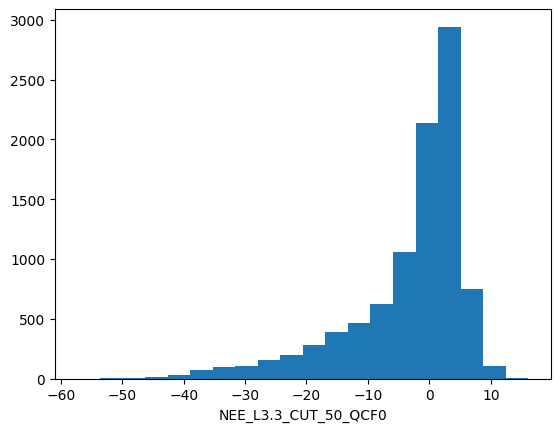

,SW_IN_POT,ppfd,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_harvest,soil_preparation_timed,sowing_timed,ts_0.3_gfXG_roll3hmean,ts_0.3_gfXG_roll6hmean,ts_0.3_gfXG_roll9hmean,ts_0.3_gfXG_lag9h_roll9hmean,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,
2023-11-22 11:15:00,508.623,100.485834,0.0,0.0,30.0,0.0,0.0,7.835438,7.881068,7.910730,8.105448,0.870527
2023-11-22 11:45:00,531.452,78.235791,0.0,0.0,30.0,0.0,0.0,7.796506,7.868452,7.894069,8.098096,0.844507
2023-11-22 12:15:00,539.106,82.407674,0.0,0.0,30.0,0.0,0.0,7.760740,7.853238,7.880673,8.085197,0.629330
2023-11-22 12:45:00,531.452,98.399892,0.0,0.0,30.0,0.0,0.0,7.751738,7.833677,7.864993,8.074308,0.602554
2023-11-22 13:15:00,508.623,117.173366,0.0,0.0,30.0,0.0,0.0,7.729686,7.810645,7.846763,8.061026,0.477717
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.000,0.000000,NaN,NaN,NaN,NaN,NaN,17.299259,17.243611,17.163580,17.054537,10.578562
2025-06-04 22:15:00,0.000,0.000000,NaN,NaN,NaN,NaN,NaN,17.299907,17.260231,17.183889,17.034259,9.416519
2025-06-04 22:45:00,0.000,0.000000,NaN,NaN,NaN,NaN,NaN,17.294907,17.268472,17.199907,17.017191,10.095010


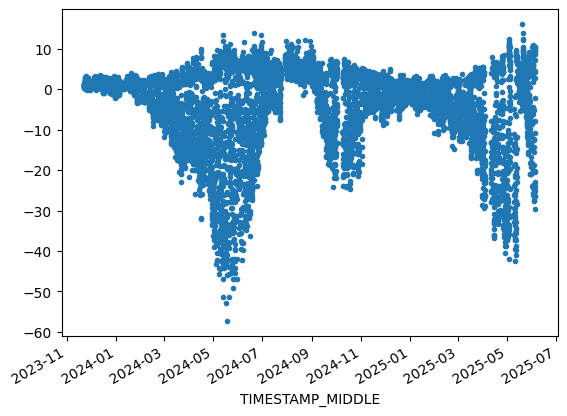

In [17]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

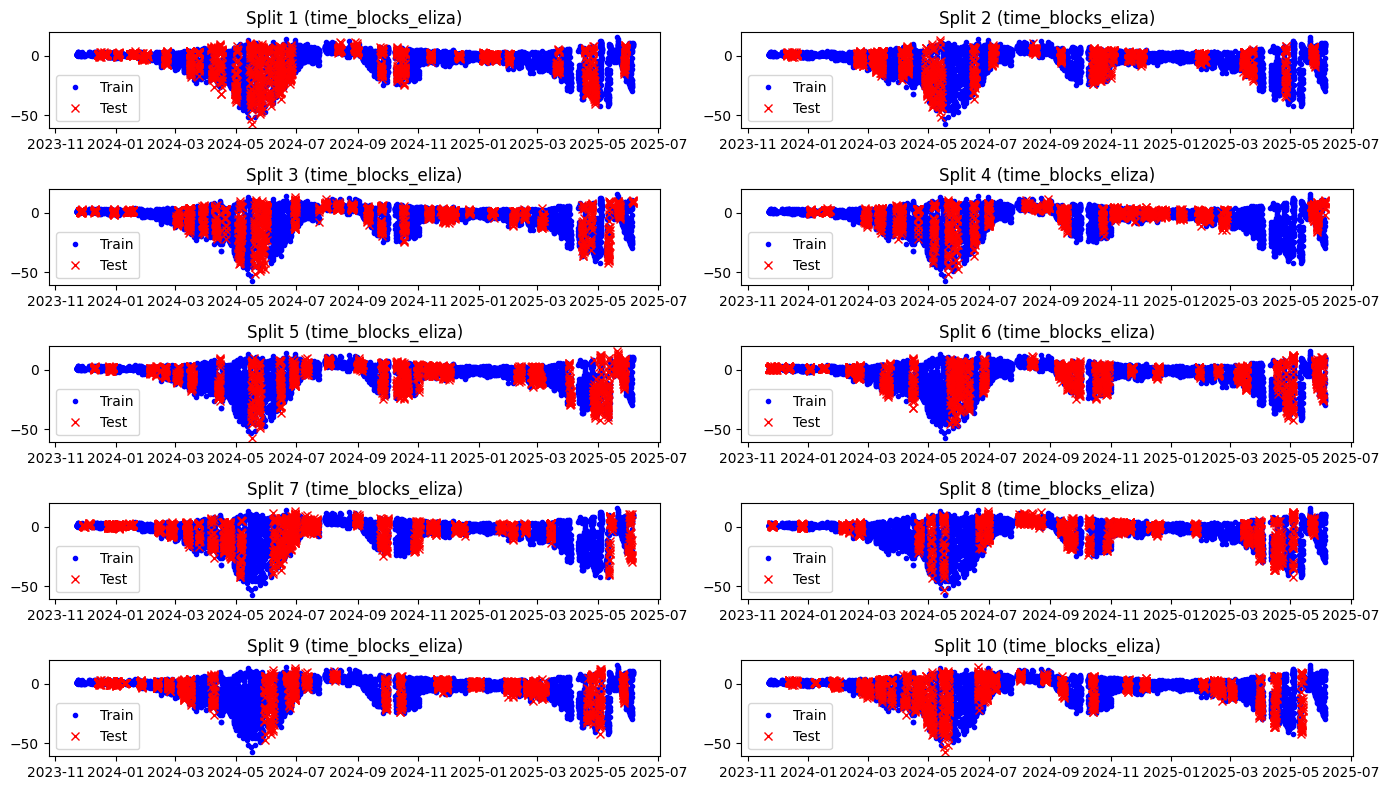

In [18]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 48, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits
    
if CROSSVAL_SPLIT == 'custom_time_blocks':
    def create_splits(X, y, n_folds=5, test_fraction=0.2, block_duration='1D',
                    min_gap='6D', buffer_gap='1D', seed=None):
        """
        Time-block CV with buffer and min_gap enforcement, allowing partial blocks to match test_fraction.
        """
        if seed is not None:
            np.random.seed(seed)

        total_rows = len(X)
        total_test_target = int(total_rows * test_fraction)
        all_times = X.index
        block_dur = pd.to_timedelta(block_duration)
        min_gap_dur = pd.to_timedelta(min_gap)
        buffer_gap_dur = pd.to_timedelta(buffer_gap)

        # Generate all possible block start times
        possible_starts = all_times[(all_times + block_dur) <= all_times[-1]]
        splits = []

        for fold in range(n_folds):
            test_indices = set()
            buffer_indices = set()
            selected_blocks = []

            shuffled_starts = np.random.permutation(possible_starts)

            for start_time in shuffled_starts:
                end_time = start_time + block_dur
                buffer_start = start_time - buffer_gap_dur
                buffer_end = end_time + buffer_gap_dur

                # Enforce min_gap between selected test blocks
                if any(abs(pd.Timedelta(start_time - sel).total_seconds()) < min_gap_dur.total_seconds()
                    for sel in selected_blocks):
                    continue

                block_mask = (all_times >= start_time) & (all_times < end_time)
                buffer_mask = (all_times >= buffer_start) & (all_times < buffer_end)

                block_idx = np.where(block_mask)[0]
                buffer_idx = np.where(buffer_mask)[0]

                if len(block_idx) == 0:
                    continue

                # Allow trimming final block if needed
                remaining = total_test_target - len(test_indices)
                if remaining <= 0:
                    break
                if len(block_idx) > remaining:
                    block_idx = block_idx[:remaining]

                # Check again for overlap with buffer
                if any(i in buffer_indices for i in block_idx):
                    continue

                test_indices.update(block_idx)
                buffer_indices.update(buffer_idx)
                selected_blocks.append(start_time)

                if len(test_indices) >= total_test_target:
                    break

            train_indices = sorted(set(range(total_rows)) - test_indices - buffer_indices)
            splits.append((np.array(train_indices), np.array(sorted(test_indices))))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [19]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 0.65}


# EXPORT 

In [20]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [21]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-09-25 00:22:54
